In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"
import keras
import bayesflow as bf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

Sample test

In [50]:
#Normal RDM (First Response)
# ————— Context —————
def context(n=None):
    if n is None:
        n = np.random.randint(1000, 1001)
    return dict(n=n)

# ————— Prior —————
def prior(nu=None, alpha=None, tau=None):
    if nu is None:
        nu = np.random.dirichlet([2, 2])
        nu = np.random.gamma(shape=5, scale=0.5) * nu
    if alpha is None:
        alpha = np.random.gamma(shape=5, scale=0.2)
    if tau is None:
        tau = np.random.exponential(0.15)
    else:
        tau = tau.item()
    return dict(nu=nu, alpha=alpha, tau=tau)

# ————— Evidence accumulation —————
def evidence_accumulation(drift, max_t, dt):
    """
    Simulate a 1D drift-diffusion process:
      dX = drift*dt + dW,  W ~ N(0, dt)

    Returns:
      t        : numpy array of time points (dt, 2dt, …, max_t)
      evidence : cumulative evidence at each t
    """
    n_steps = int(np.floor(max_t / dt))
    t = np.linspace(dt, n_steps * dt, n_steps)
    # Gaussian noise with variance dt
    noise = np.random.normal(loc=0.0, scale=np.sqrt(dt), size=n_steps)
    # Euler–Maruyama integration of drift + noise
    evidence = np.cumsum(drift * dt + noise)
    return t, evidence

# ————— Trial —————
def trial(nu, alpha, tau, max_t, dt):
    response = -1
    min_t = max_t
    for resp, drift in enumerate(nu):
        t, evidence = evidence_accumulation(drift, max_t, dt)
        passage = np.argmax(evidence > alpha)
        t = max_t if passage == 0 else t[passage]
        if t < min_t:
            min_t = t
            response = resp
    # return RT and whether it was the “correct” accumulator
    return min_t + tau, (response == 1)

# ————— Likelihood (simulate n trials) —————
def likelihood(n, nu, alpha, tau, max_t=3.0, dt=0.02, max_n=1000):
    Time1     = np.full(max_n, np.nan)
    Correct   = np.full(max_n, False, dtype=bool)
    DoubleResp= np.full(max_n, False, dtype=bool)
    Time2     = np.full(max_n, np.nan)

    for i in range(n):
        rt, is_corr = trial(nu, alpha, tau, max_t, dt)
        Time1[i]   = rt
        Correct[i] = is_corr

    return dict(
        Correct=Correct,
        Time1=Time1,
        DoubleResp=DoubleResp,
        Time2=Time2
    )

# ————— Build simulator —————
simulator = bf.make_simulator([context, prior, likelihood])


In [4]:
adapter = (
    bf.Adapter()
      # tell it which simulator outputs are your summaries
    .as_set(["Correct", "Time1"])
      # keep your positivity constraints & standardization on parameters
    .constrain(["nu", "alpha", "tau"], lower=0)
    .standardize(include="nu",    mean=0.7,  std=1.2)
    .standardize(include="alpha", mean=0.5,  std=0.7)
    .standardize(include="tau",   mean=-2.5, std=1.3)
      # pack your inference inputs (the model parameters) into one vector
    .concatenate(["nu", "alpha", "tau"],
                 into="inference_variables")
      # pack your two summaries into one vector (for DeepSet)
    .concatenate(["Correct", "Time1"],
                 into="summary_variables")
)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    inference_network=bf.networks.CouplingFlow(
      permutation="swap",
      subnet_kwargs=dict(dropout=False)
    ),
    summary_network=bf.networks.DeepSet(
      base_distribution="normal",
      dropout=False
    ),

    inference_variables   = ["nu", "alpha", "tau"],
    inference_conditions  = ["n"],            # <-- n lives here
    summary_variables     = ["Correct", "Time1"]
)


In [5]:
train_data = simulator.sample(2_500)
validation_data = simulator.sample(1_000)

In [6]:
history=workflow.fit_offline(
    data=train_data, 
    epochs=50, 
    batch_size=120, 
    validation_data=validation_data
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - loss: 6.1085 - loss/inference_loss: 5.3405 - loss/summary_loss: 0.7680 - val_loss: 5.3919 - val_loss/inference_loss: 5.0575 - val_loss/summary_loss: 0.3344
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - loss: 4.9203 - loss/inference_loss: 4.6060 - loss/summary_loss: 0.3143 - val_loss: 4.8231 - val_loss/inference_loss: 4.4410 - val_loss/summary_loss: 0.3822
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 4.4686 - loss/inference_loss: 4.1598 - loss/summary_loss: 0.3088 - val_loss: 4.3154 - val_loss/inference_loss: 4.0430 - val_loss/summary_loss: 0.2724
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 4.0806 - loss/inference_loss: 3.7982 - loss/summary_loss: 0.2825 - val_loss: 4.1082 - val_loss/inference_loss: 3.8333 - val_loss/summary_loss: 0.2749
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - loss: 3.8125 - loss/inference_loss: 3.5348 - loss/summary_loss: 0.2776 - val_loss: 3.9172 - val_loss/inference_loss:

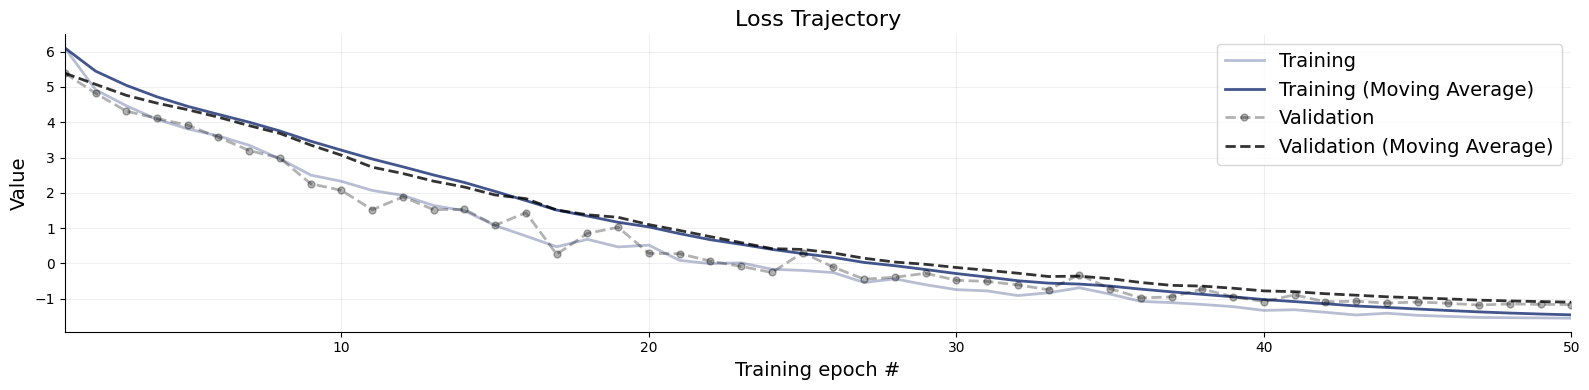

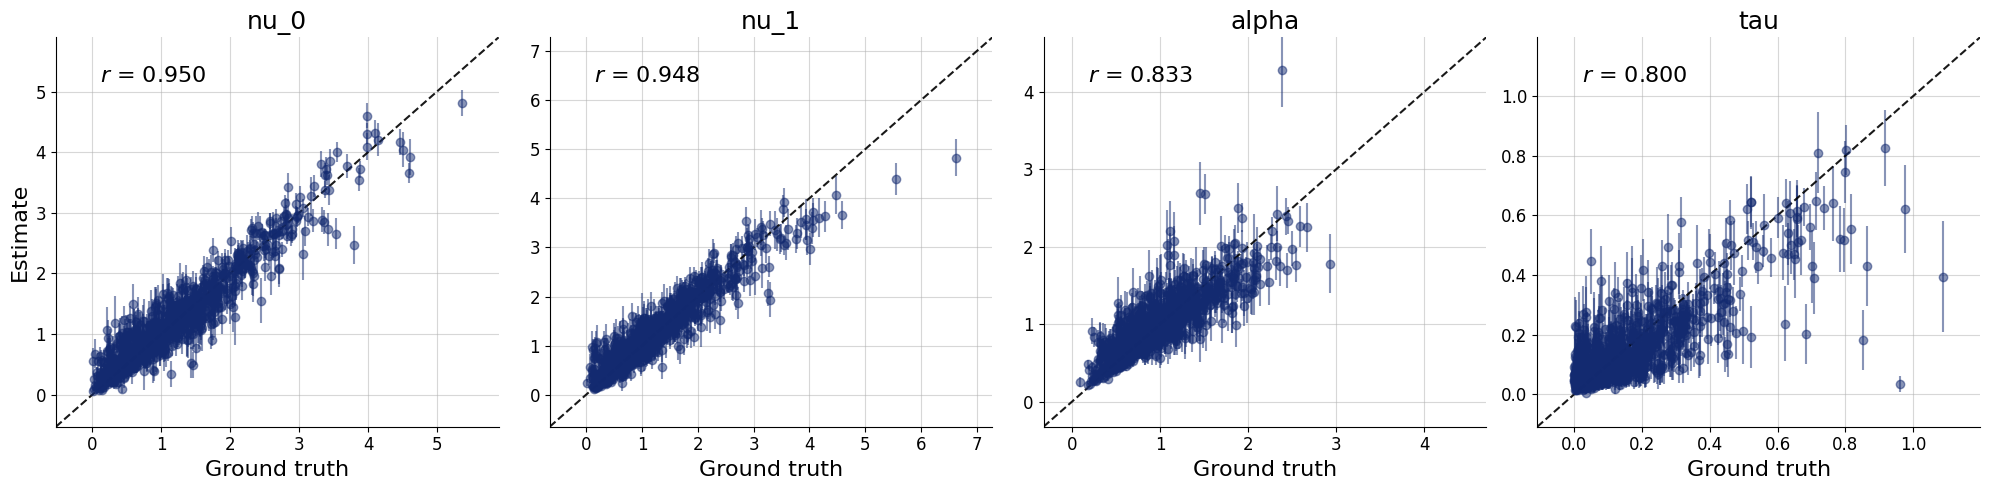

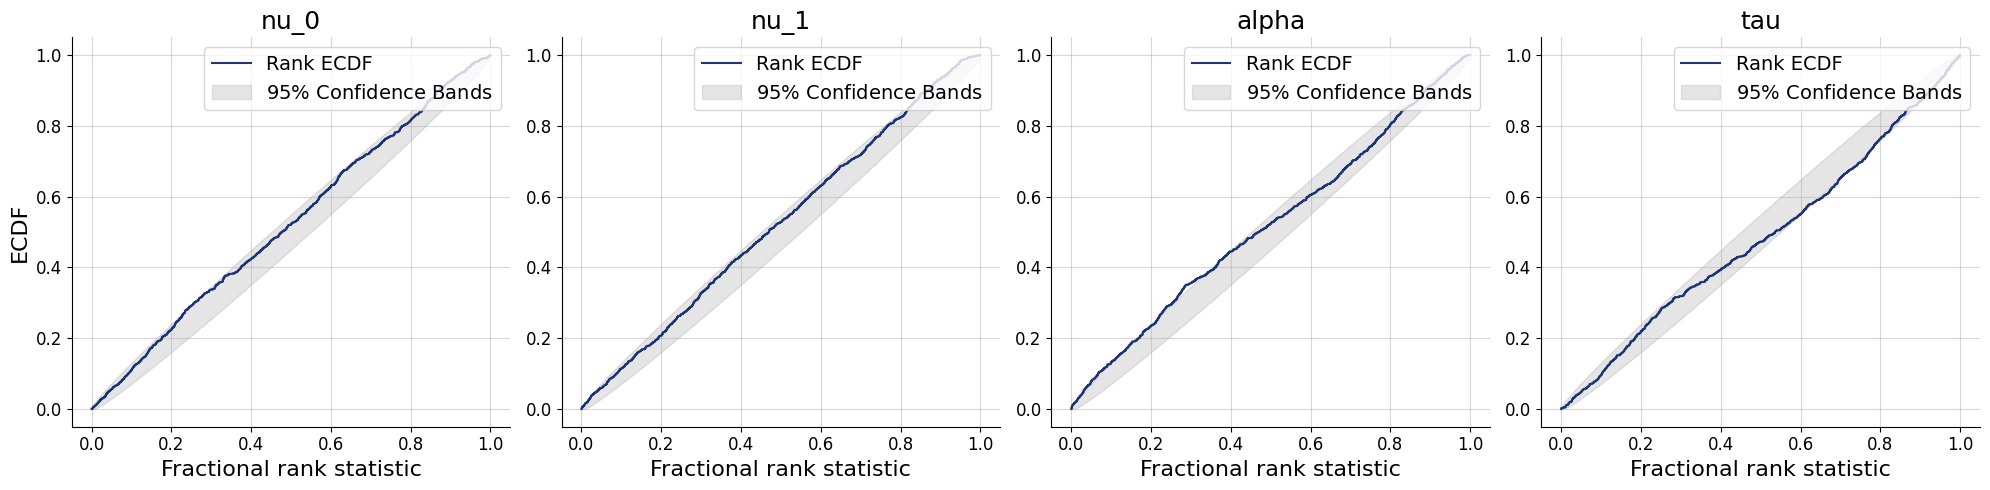

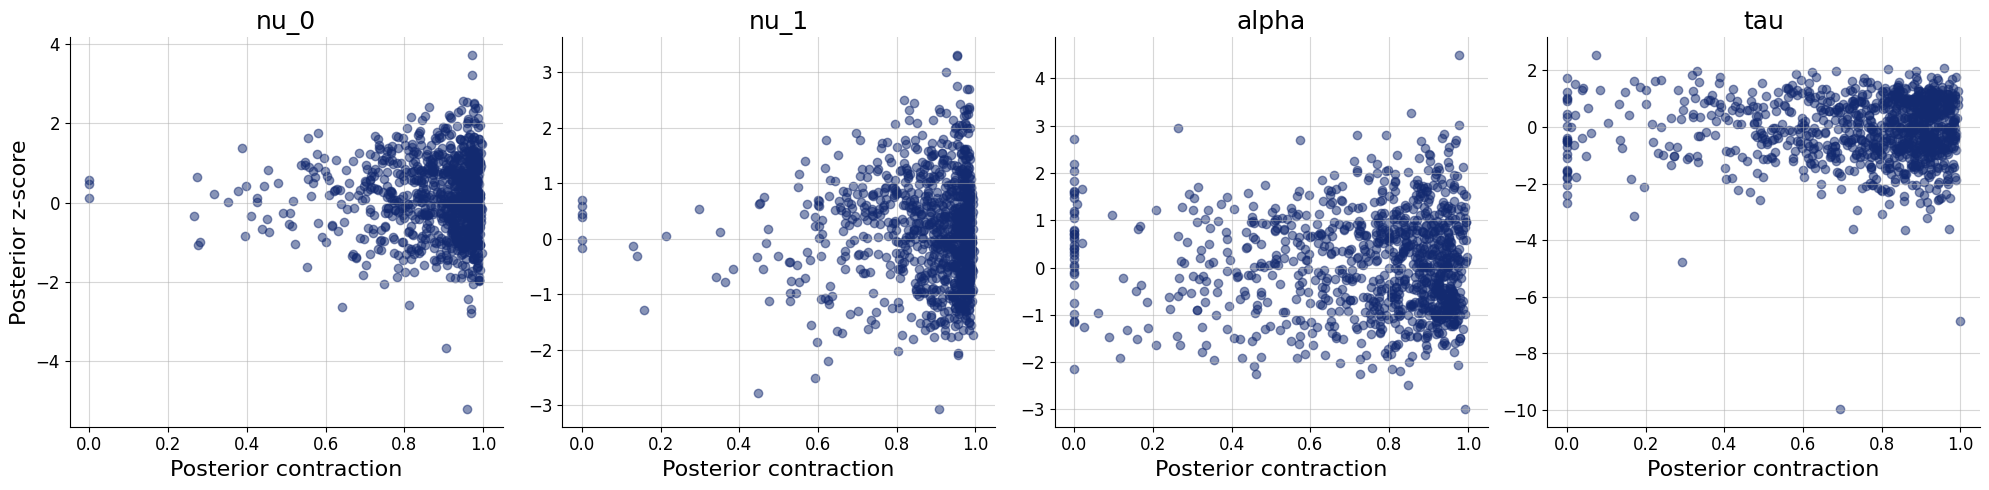

In [7]:
test_data = simulator.sample(1_000)
plots=workflow.plot_default_diagnostics(test_data=test_data)

In [8]:
df =  pd.read_csv("data/double_responses.csv")

C:\Users\MOHOR\AppData\Local\Temp\ipykernel_30712\853547600.py:1: DtypeWarning: Columns (3,5) have mixed types. Specify dtype option on import or set low_memory=False.
  df =  pd.read_csv("D:/Users/MOHOR/Downloads/double responses.csv")


In [10]:
df = df[["list_id", "Correct", "Time1", "DoubleResp", "Time2"]]


In [11]:
df_small = (
    df
    .groupby("list_id", group_keys=False)
    .sample(n=1000, random_state=42)
    .reset_index(drop=True)
)


In [12]:
max_n = 1000
grouped = df_small.groupby("list_id", sort=False)

conditions = {
    # summary_variables (rank‐3 arrays: n_lists × 200 × 1)
    "Correct": np.stack(
        [g["Correct"].values.reshape(max_n, 1) for _, g in grouped],
        axis=0
    ),
    "Time1":   np.stack(
        [g["Time1"].values.reshape(max_n, 1)   for _, g in grouped],
        axis=0
    ),
    # inference_conditions (n_lists,)
    "n": np.array([g.shape[0] for _, g in grouped])
}

print({k: v.shape for k, v in conditions.items()})

{'Correct': (4, 1000, 1), 'Time1': (4, 1000, 1), 'n': (4,)}


In [16]:
import numpy as np

max_n   = 1000
grouped = df_small.groupby("list_id", sort=False)

# build every summary as float32
C  = np.stack([g["Correct"].values.reshape(max_n,1).astype(np.float32)
               for _, g in grouped], axis=0)
T1 = np.stack([g["Time1"].values.reshape(max_n,1).astype(np.float32)
               for _, g in grouped], axis=0)
DR = np.stack([g["DoubleResp"].values.reshape(max_n,1).astype(np.float32)
               for _, g in grouped], axis=0)
T2 = np.stack([g["Time2"].values.reshape(max_n,1).astype(np.float32)
               for _, g in grouped], axis=0)

# and n as int32
n  = np.array([g.shape[0] for _, g in grouped], dtype=np.int32)

conditions = {
    "Correct":    C,
    "Time1":      T1,
    "DoubleResp": DR,
    "Time2":      T2,
    "n":          n
}

# sanity‐check
for k,v in conditions.items():
    print(k, v.dtype, v.shape)
# you should see float32 for all except n=int32

# now sample without error:
posterior_samples = workflow.sample(
    num_samples = 1000,
    conditions  = conditions
)


Correct float32 (4, 1000, 1)
Time1 float32 (4, 1000, 1)
DoubleResp float32 (4, 1000, 1)
Time2 float32 (4, 1000, 1)
n int32 (4,)


In [17]:
posterior_samples = workflow.sample(
    conditions=conditions,
    num_samples=1000
)

In [18]:
first_list_id = next(iter(grouped.groups))
print("First list_id:", first_list_id)

data_first = grouped.get_group(first_list_id)
print("Data for first participant shape:", data_first.shape)

posterior_first = {
    key: arr[0]
    for key, arr in posterior_samples.items()
}
print("Posterior for first participant:")
for name, samples in posterior_first.items():
    print(f"  {name}: {samples.shape}")

First list_id: 1.0
Data for first participant shape: (1000, 5)
Posterior for first participant:
  nu: (1000, 2)
  alpha: (1000, 1)
  tau: (1000, 1)


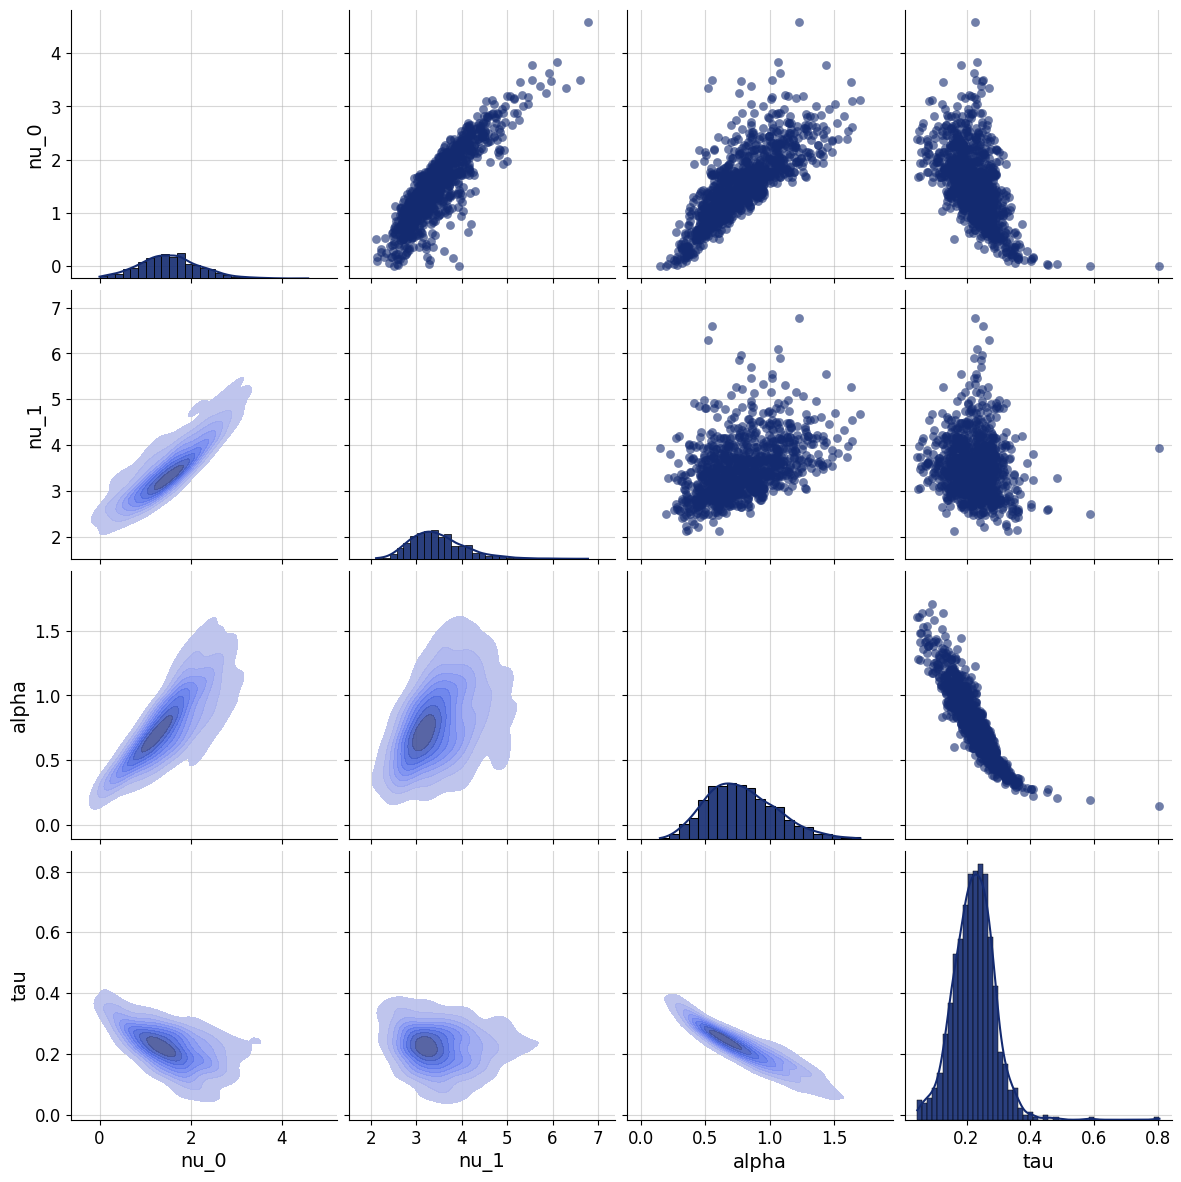

In [19]:

f=bf.diagnostics.pairs_posterior(estimates=posterior_first)

C:\Users\MOHOR\AppData\Local\Temp\ipykernel_30712\2863830634.py:61: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Time1[i]   = rt


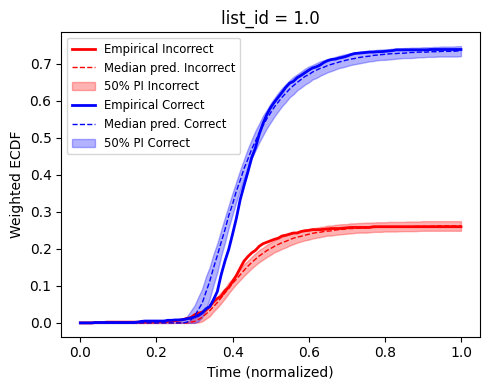

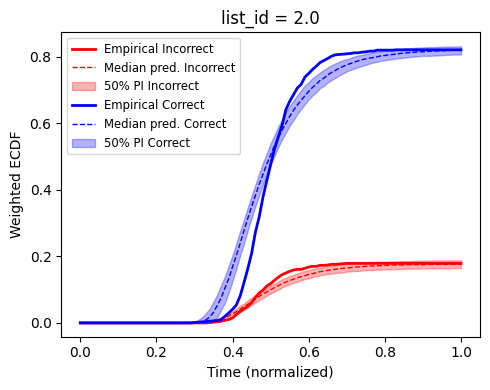

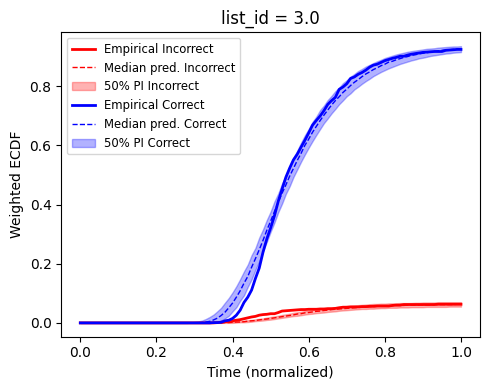

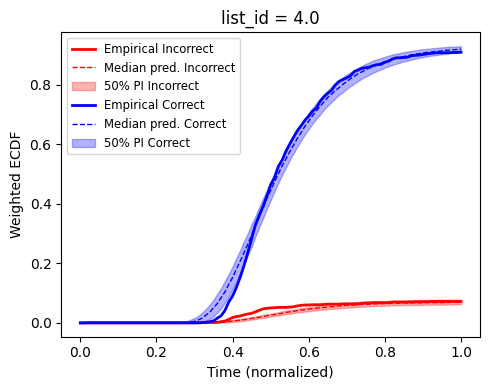

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# ——— ECDF on a fixed grid (corrected) ——————————————————————
def ecdf_grid(Time1, Correct, t_grid):
    # ensure proper dtypes
    Time1   = np.asarray(Time1,   dtype=float)
    Correct = np.asarray(Correct, dtype=bool)

    valid    = ~np.isnan(Time1)
    mask_inc = valid & np.logical_not(Correct)
    mask_cor = valid & Correct

    # relative frequencies of each response
    total_valid = valid.sum()
    p_inc = mask_inc.sum() / total_valid if total_valid > 0 else 0.0
    p_cor = mask_cor.sum() / total_valid if total_valid > 0 else 0.0

    # for each cutoff x, fraction of RTs ≤ x
    ec0 = p_inc * np.array([
        np.mean(Time1[mask_inc] <= x) if mask_inc.any() else 0.0
        for x in t_grid
    ])
    ec1 = p_cor * np.array([
        np.mean(Time1[mask_cor] <= x) if mask_cor.any() else 0.0
        for x in t_grid
    ])

    return np.stack([ec0, ec1], axis=0)  # shape (2, len(t_grid))


# Colors & labels
cols   = ["red", "blue"]
labels = ["Incorrect", "Correct"]

# Common grid (normalized 0→1)
t_grid = np.linspace(0, 1, 101)

# Loop over each list_id
for idx, list_id in enumerate(grouped.groups):
    df_i = grouped.get_group(list_id)

    # 1) empirical ECDF
    emp_ecdf = ecdf_grid(
        Time1   = df_i["Time1"].values,
        Correct = df_i["Correct"].values,
        t_grid  = t_grid
    )

    # 2) posterior draws for this participant
    post_i = {param: arr[idx] for param, arr in posterior_samples.items()}
    num_pp = post_i["alpha"].shape[0]

    # 3) simulate posterior‐predictive ECDFs
    pp_ecdfs = np.zeros((num_pp, 2, len(t_grid)))
    for j in range(num_pp):
        out = likelihood(
            n        = df_i.shape[0],
            nu       = post_i["nu"][j],
            alpha    = post_i["alpha"][j],
            tau      = post_i["tau"][j],
            max_n    = df_i.shape[0]
        )
        pp_ecdfs[j] = ecdf_grid(
            Time1   = out["Time1"],
            Correct = out["Correct"],
            t_grid  = t_grid
        )

    # 4) compute 25/50/75% quantiles
    q_ecdf = np.quantile(pp_ecdfs, [0.25, 0.5, 0.75], axis=0)

    # 5) plot
    plt.figure(figsize=(5, 4))
    for k, lab in enumerate(labels):
        plt.plot(   t_grid, emp_ecdf[k],   color=cols[k], lw=2, label=f"Empirical {lab}")
        plt.plot(   t_grid, q_ecdf[1, k],  color=cols[k], lw=1, ls="--", label=f"Median pred. {lab}")
        plt.fill_between(
            t_grid,
            q_ecdf[0, k],
            q_ecdf[2, k],
            color=cols[k],
            alpha=0.3,
            label=f"50% PI {lab}"
        )

    plt.xlabel("Time (normalized)")
    plt.ylabel("Weighted ECDF")
    plt.title(f"list_id = {list_id}")
    plt.legend(fontsize="small", loc="upper left")
    plt.tight_layout()
    plt.show()


Variation 1 model

In [26]:
def trial(nu, alpha, tau, max_t, dt):
    """
    Returns:
      Time1       : first decision time + tau
      Correct     : bool, whether accumulator 1 wins
      DoubleResp  : bool, whether the loser ever crossed before max_t
      Time2       : second decision time + tau, or 0.0 if no second response
    """
    # 1) get first‐passage times for each accumulator
    passages = []
    for drift in nu:
        t, ev = evidence_accumulation(drift, max_t, dt)
        idxs = np.where(ev >= alpha)[0]
        if idxs.size:
            passages.append(t[idxs[0]])
        else:
            passages.append(max_t)
    T1, T2 = passages

    # 2) first response
    winner   = int(np.argmin(passages))
    Time1    = passages[winner] + tau
    Correct  = (winner == 1)

    # 3) second response (if any)
    loser    = 1 - winner
    if passages[loser] < max_t:
        DoubleResp = True
        Time2      = passages[loser] + tau
    else:
        DoubleResp = False
        Time2      = 0.0   # or np.nan, but downstream code must handle it

    return Time1, Correct, DoubleResp, Time2


def likelihood(n, nu, alpha, tau, max_t=3.0, dt=0.02, max_n=1000):
    Time1      = np.full(max_n, np.nan)
    Time2      = np.full(max_n, np.nan)
    Correct    = np.zeros(max_n, dtype=bool)
    DoubleResp = np.zeros(max_n, dtype=bool)

    for i in range(n):
        t1, corr, dbl, t2 = trial(nu, alpha, tau, max_t, dt)
        Time1[i]      = t1
        Correct[i]    = corr
        DoubleResp[i] = dbl
        Time2[i]      = t2

    # encode missing second responses as zero
    Time2 = np.where(DoubleResp, Time2, 0.0)

    return dict(
        Correct    = Correct,
        Time1      = Time1,
        DoubleResp = DoubleResp,
        Time2      = Time2
    )
    simulator = bf.make_simulator([context, prior, likelihood])


In [27]:
# draw a single “batch” of size 1
batch = simulator.sample(1)

# batch is a dict: keys are your context/priors/likelihood outputs,
# values are NumPy arrays of shape (batch_size, …)
for name, arr in batch.items():
    print(
      f"{name:12s}"
      f" → type={type(arr)}, "
      f"dtype={getattr(arr,'dtype',None)}, "
      f"shape={arr.shape}"
    )


n            → type=<class 'numpy.ndarray'>, dtype=int32, shape=(1, 1)
nu           → type=<class 'numpy.ndarray'>, dtype=float64, shape=(1, 2)
alpha        → type=<class 'numpy.ndarray'>, dtype=float64, shape=(1, 1)
tau          → type=<class 'numpy.ndarray'>, dtype=float64, shape=(1, 1)
Correct      → type=<class 'numpy.ndarray'>, dtype=bool, shape=(1, 1000)
Time1        → type=<class 'numpy.ndarray'>, dtype=float64, shape=(1, 1000)
DoubleResp   → type=<class 'numpy.ndarray'>, dtype=bool, shape=(1, 1000)
Time2        → type=<class 'numpy.ndarray'>, dtype=float64, shape=(1, 1000)


In [28]:
import bayesflow as bf

# ─── 7) ADAPTER ────────────────────────────────────────────
adapter = (
    bf.Adapter()
      # which simulator outputs are your summaries
    .as_set(["Correct", "Time1", "DoubleResp", "Time2"])

      # enforce positivity on parameters
    .constrain(["nu", "alpha", "tau"], lower=0)

      # (keep the same standardization as before)
    .standardize(include="nu",    mean=0.7,  std=1.2)
    .standardize(include="alpha", mean=0.5,  std=0.7)
    .standardize(include="tau",   mean=-2.5, std=1.3)

      # pack your inference inputs into one vector
    .concatenate(["nu", "alpha", "tau"],
                 into="inference_variables")

      # pack all four summaries into one vector
    .concatenate(["Correct", "Time1", "DoubleResp", "Time2"],
                 into="summary_variables")
)

# ─── 8) WORKFLOW ───────────────────────────────────────────
workflow = bf.BasicWorkflow(
    simulator           = simulator,
    adapter             = adapter,

    inference_network   = bf.networks.CouplingFlow(
                              permutation="swap",
                              subnet_kwargs=dict(dropout=False)
                          ),

    summary_network     = bf.networks.DeepSet(
                              base_distribution="normal",
                              dropout=False
                          ),

    inference_variables   = ["nu", "alpha", "tau"],
    inference_conditions  = ["n"],   # n comes from context
    summary_variables     = ["Correct", "Time1", "DoubleResp", "Time2"]
)


In [29]:
train_data      = simulator.sample(2_500)
validation_data = simulator.sample(1_000)



In [33]:
history=workflow.fit_offline(
    data=train_data, 
    epochs=50, 
    batch_size=120, 
    validation_data=validation_data
)

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - loss: 6.7774 - loss/inference_loss: 5.3242 - loss/summary_loss: 1.4532 - val_loss: 5.4526 - val_loss/inference_loss: 4.8465 - val_loss/summary_loss: 0.6061
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - loss: 4.8824 - loss/inference_loss: 4.3861 - loss/summary_loss: 0.4963 - val_loss: 4.4994 - val_loss/inference_loss: 4.0833 - val_loss/summary_loss: 0.4161
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 52s 2s/step - loss: 4.2055 - loss/inference_loss: 3.7702 - loss/summary_loss: 0.4353 - val_loss: 4.0320 - val_loss/inference_loss: 3.5574 - val_loss/summary_loss: 0.4746
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 89s 3s/step - loss: 3.5000 - loss/inference_loss: 3.0551 - loss/summary_loss: 0.4449 - val_loss: 3.5625 - val_loss/inference_loss: 3.0701 - val_loss/summary_loss: 0.4924
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 60s 3s/step - loss: 3.1071 - loss/inference_loss: 2.6773 - loss/summary_loss: 0.4298 - val_loss: 3.1099 - val_loss/inference_loss

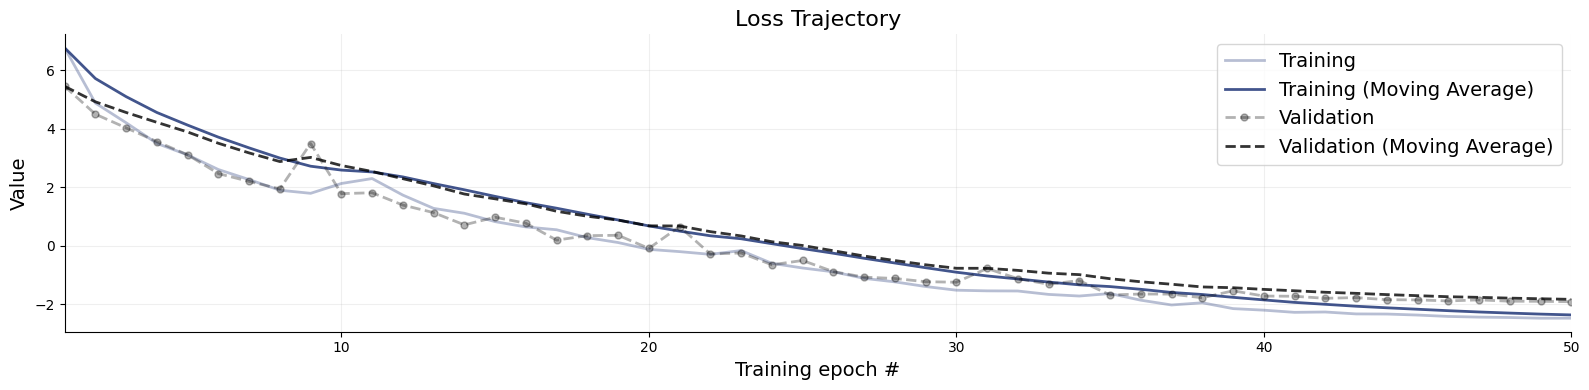

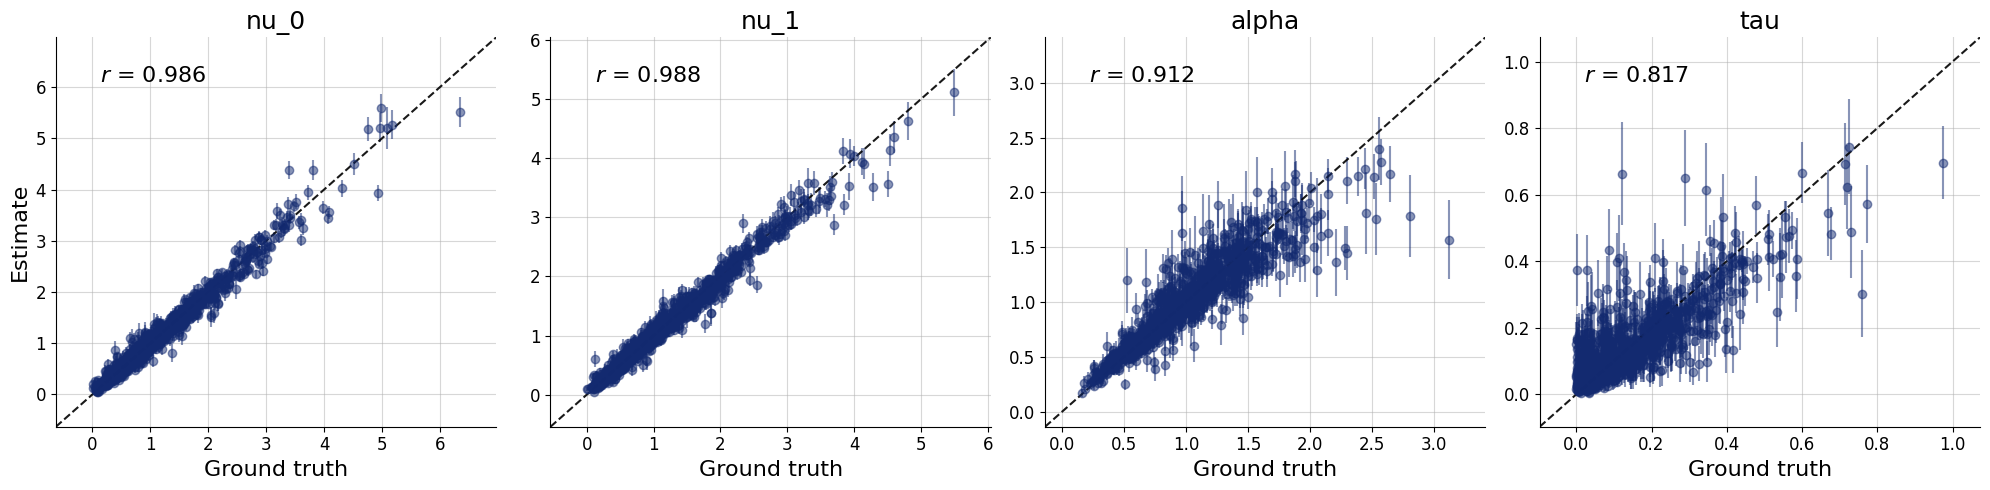

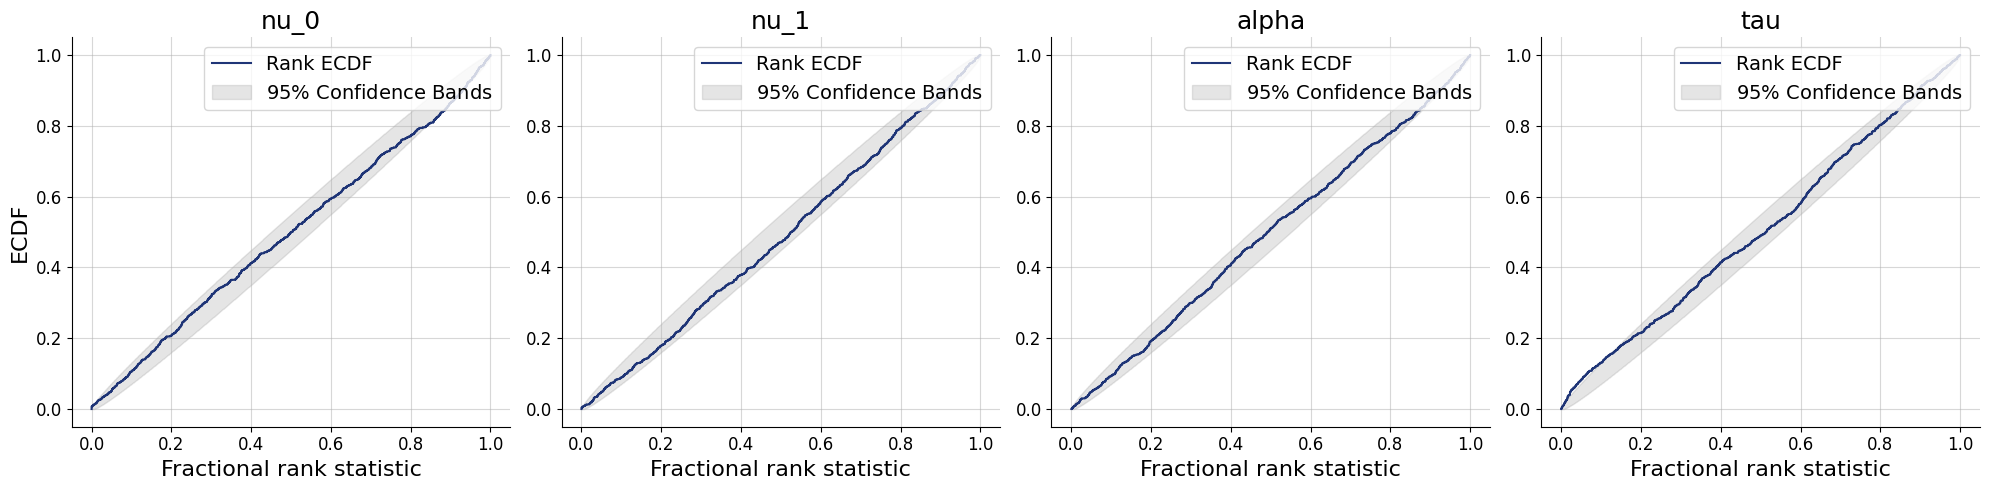

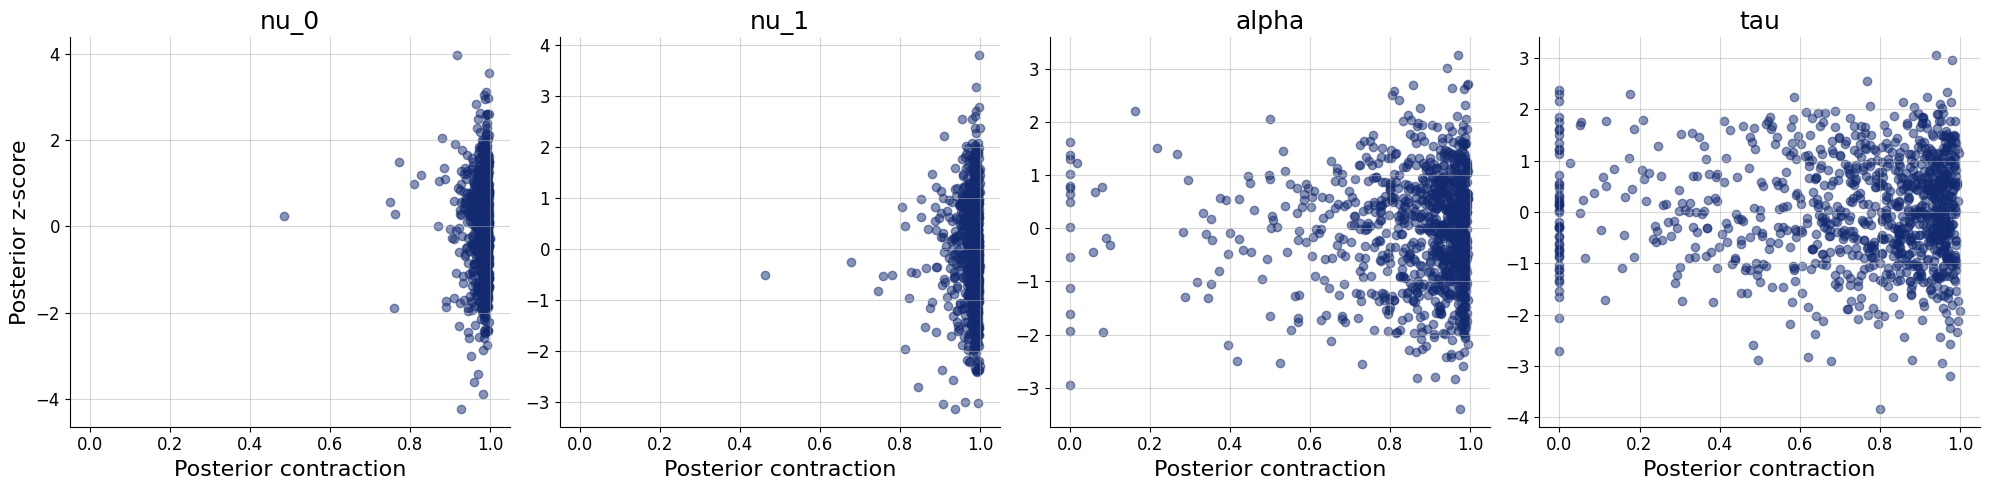

In [34]:
test_data = simulator.sample(1_000)

# automatic calibration / coverage / marginal‐quantile plots
ppc_plots = workflow.plot_default_diagnostics(test_data=test_data)

In [37]:
df_dr =  pd.read_csv("data/double_responses.csv") 
df_dr= df_dr[["list_id", "Correct", "Time1", "DoubleResp", "Time2"]] 
df_small_dr = ( 
    df_dr
    .groupby("list_id", group_keys=False)
    .sample(n=1000, random_state=42)
    .reset_index(drop=True)
)

In [38]:
df_small_dr.head(10)

,list_id,Correct,Time1,DoubleResp,Time2
0,1,True,0.4024,False,NaN
1,1,True,0.3954,False,NaN
2,1,False,0.2910,False,NaN
3,1,True,0.4390,False,NaN
4,1,True,0.3686,False,NaN
5,1,True,0.3602,False,NaN
6,1,True,0.4158,False,NaN
7,1,False,0.4406,False,NaN
8,1,True,0.3681,False,NaN
9,1,True,0.5468,False,NaN


In [39]:
# safe, avoids chained‐assignment warnings
df_small_dr["Time2"] = df_small_dr["Time2"].fillna(0.0)
df_small_dr["Time2"].isna().sum()  # should print 0


0

In [40]:
df_small_dr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   list_id     4000 non-null   int64  
 1   Correct     4000 non-null   bool   
 2   Time1       4000 non-null   float64
 3   DoubleResp  4000 non-null   bool   
 4   Time2       4000 non-null   float64
dtypes: bool(2), float64(2), int64(1)
memory usage: 101.7 KB


In [41]:
max_n   = 1000
grouped = df_small_dr.groupby("list_id", sort=False)
n_lists = len(grouped)

conditions = {
    # summary_variables: each is shape (n_lists, max_n, 1)
    "Correct": np.stack(
        [g["Correct"].values.reshape(max_n, 1)    for _, g in grouped],
        axis=0
    ),
    "Time1":   np.stack(
        [g["Time1"].values.reshape(max_n, 1)      for _, g in grouped],
        axis=0
    ),
    "DoubleResp": np.stack(
        [g["DoubleResp"].values.reshape(max_n, 1) for _, g in grouped],
        axis=0
    ),
    "Time2":   np.stack(
        [g["Time2"].values.reshape(max_n, 1)      for _, g in grouped],
        axis=0
    ),

    # inference_conditions: number of trials per list (shape (n_lists,))
    "n": np.array([g.shape[0] for _, g in grouped])
}

print({k: v.shape for k, v in conditions.items()})
# => {
#   'Correct':    (n_lists, 300, 1),
#   'Time1':      (n_lists, 300, 1),
#   'DoubleResp': (n_lists, 300, 1),
#   'Time2':      (n_lists, 300, 1),
#   'n':          (n_lists,)
# }


{'Correct': (4, 1000, 1), 'Time1': (4, 1000, 1), 'DoubleResp': (4, 1000, 1), 'Time2': (4, 1000, 1), 'n': (4,)}


In [42]:
posterior_samples = workflow.sample(
    conditions=conditions,
    num_samples=1000
)


In [43]:
for name, arr in posterior_samples.items():
    # arr is a (num_samples, …) numpy array
    total = arr.size
    n_nan = np.isnan(arr).sum()
    pct  = 100 * n_nan / total
    print(f"{name:8s}: {n_nan}/{total} NaNs ({pct:.1f}%)")

nu      : 0/8000 NaNs (0.0%)
alpha   : 0/4000 NaNs (0.0%)
tau     : 0/4000 NaNs (0.0%)


In [44]:
# 1) get an ordered list of your group keys
group_keys = list(grouped.groups.keys())

# 2) pick the “first” one (or any by index)
first_list_id = group_keys[0]
print("First list_id:", first_list_id)

# 3) grab its data
data_first = grouped.get_group(first_list_id)
print("Data for first participant shape:", data_first.shape)

# 4) find its index in that list
idx = group_keys.index(first_list_id)

# 5) pull out the matching posterior slice
#    each posterior_samples[k].shape == (n_groups, n_draws, param_dim)
posterior_first = {
    key: arr[idx]   # take the idx-th “row”
    for key, arr in posterior_samples.items()
}

print("Posterior for first participant:")
for name, samples in posterior_first.items():
    print(f"  {name}: {samples.shape}")


First list_id: 1
Data for first participant shape: (1000, 5)
Posterior for first participant:
  nu: (1000, 2)
  alpha: (1000, 1)
  tau: (1000, 1)


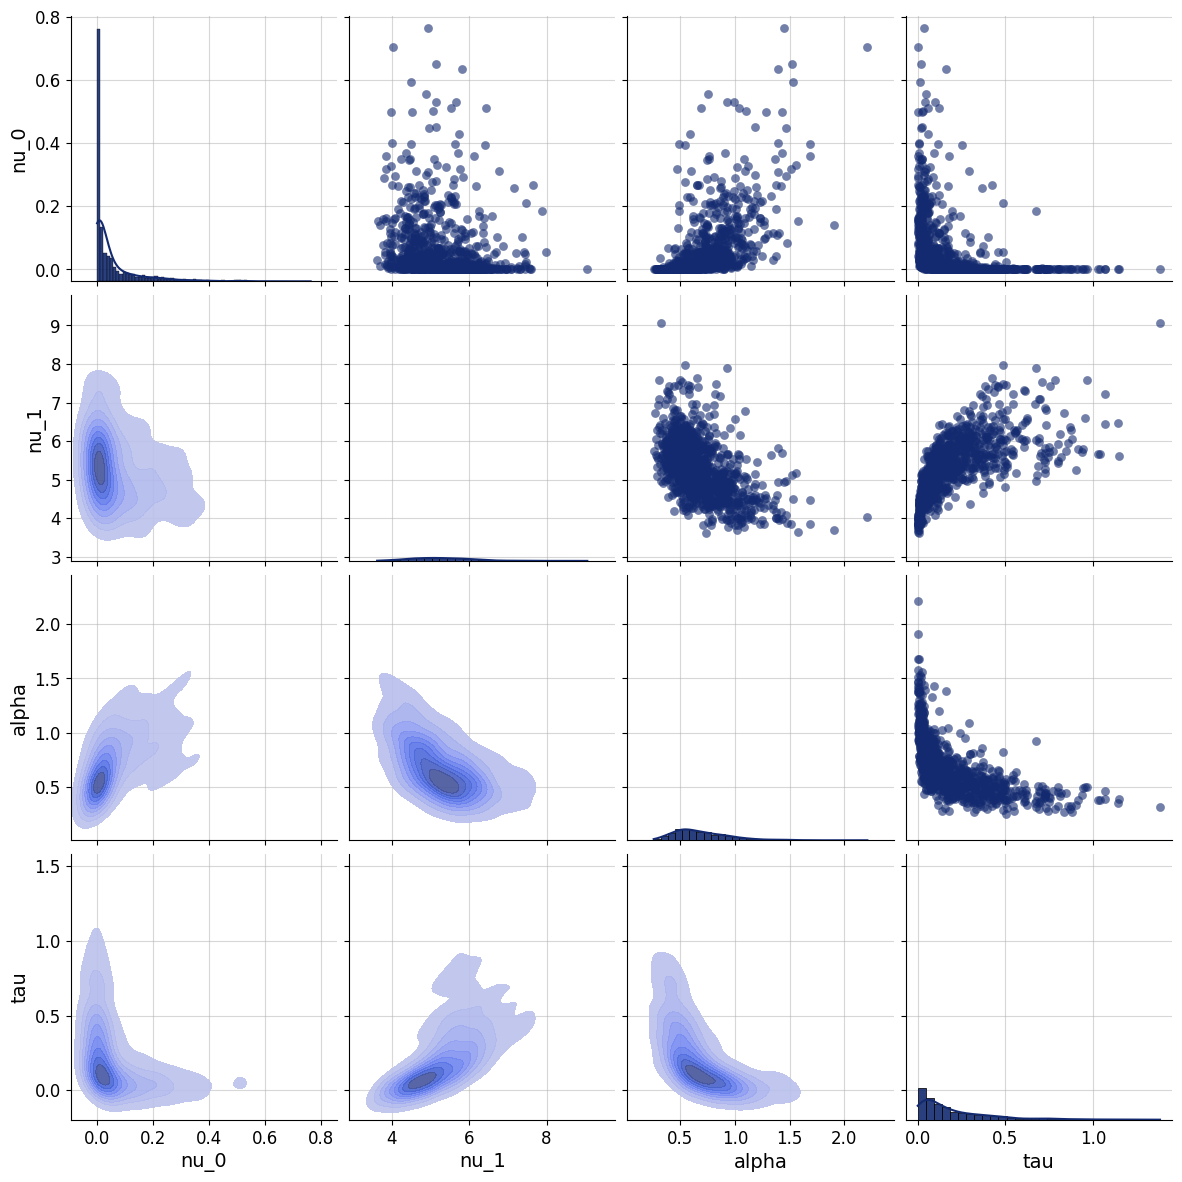

In [45]:
f=bf.diagnostics.pairs_posterior(estimates=posterior_first)

In [55]:
# --- participant 2 -------------------------------------------------
second_list_id = group_keys[1]          # index 1
print("Second list_id:", second_list_id)

data_second = grouped.get_group(second_list_id)
print("Data shape:", data_second.shape)

posterior_second = {
    key: arr[1]                         # row 1 of each array
    for key, arr in posterior_samples.items()
}

print("Posterior shapes for participant 2:")
for name, arr in posterior_second.items():
    print(f"  {name}: {arr.shape}")



Second list_id: 2
Data shape: (1000, 5)
Posterior shapes for participant 2:
  nu: (1000, 2)
  alpha: (1000, 1)
  tau: (1000, 1)


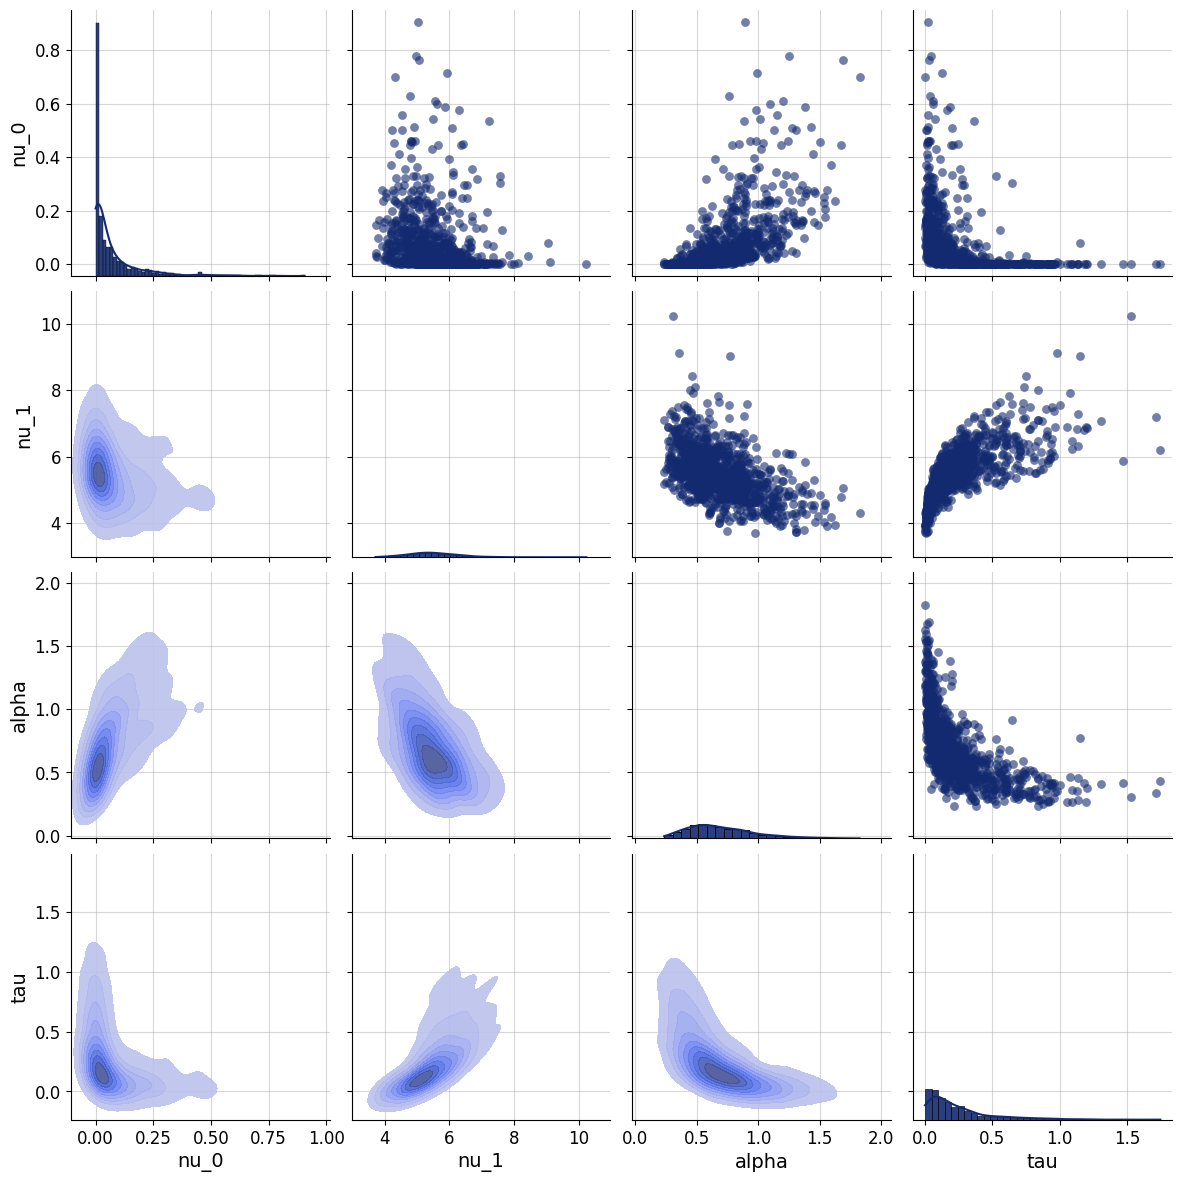

In [56]:
f=bf.diagnostics.pairs_posterior(estimates=posterior_second)

In [57]:
# --- participant 3 -------------------------------------------------
third_list_id = group_keys[2]           # index 2
print("Third list_id:", third_list_id)

data_third = grouped.get_group(third_list_id)
print("Data shape:", data_third.shape)

posterior_third = {
    key: arr[2]                         # row 2 of each array
    for key, arr in posterior_samples.items()
}

print("Posterior shapes for participant 3:")
for name, arr in posterior_third.items():
    print(f"  {name}: {arr.shape}")


Third list_id: 3
Data shape: (1000, 5)
Posterior shapes for participant 3:
  nu: (1000, 2)
  alpha: (1000, 1)
  tau: (1000, 1)


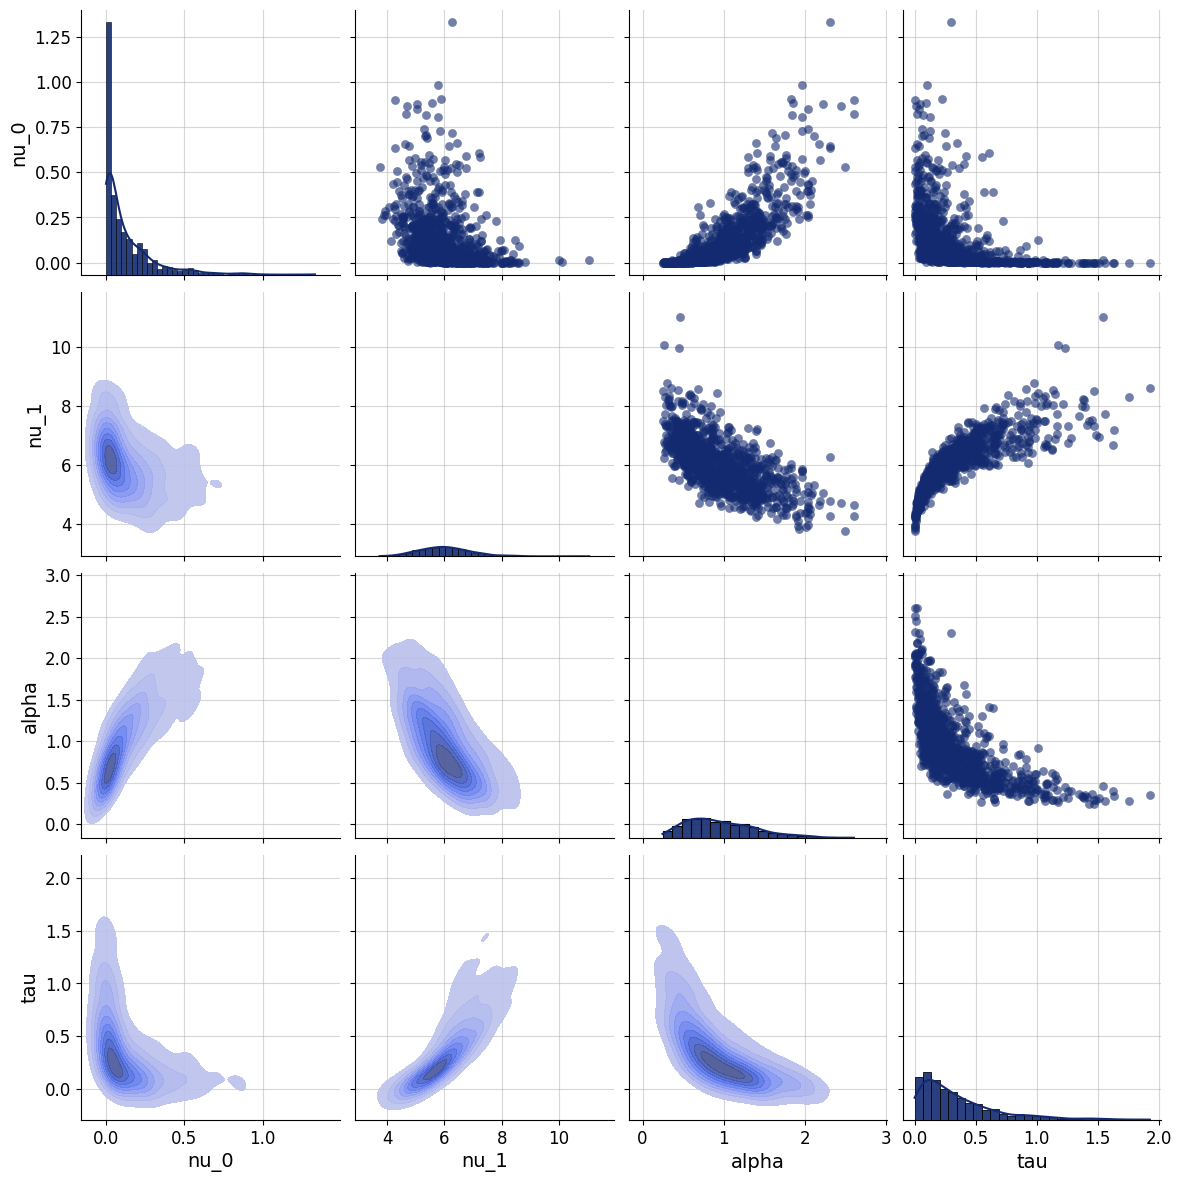

In [58]:
f=bf.diagnostics.pairs_posterior(estimates=posterior_third)

In [59]:
# --- participant 4 -------------------------------------------------
fourth_list_id = group_keys[3]          # index 3
print("Fourth list_id:", fourth_list_id)

data_fourth = grouped.get_group(fourth_list_id)
print("Data shape:", data_fourth.shape)

posterior_fourth = {
    key: arr[3]                         # row 3 of each array
    for key, arr in posterior_samples.items()
}

print("Posterior shapes for participant 4:")
for name, arr in posterior_fourth.items():
    print(f"  {name}: {arr.shape}")


Fourth list_id: 4
Data shape: (1000, 5)
Posterior shapes for participant 4:
  nu: (1000, 2)
  alpha: (1000, 1)
  tau: (1000, 1)


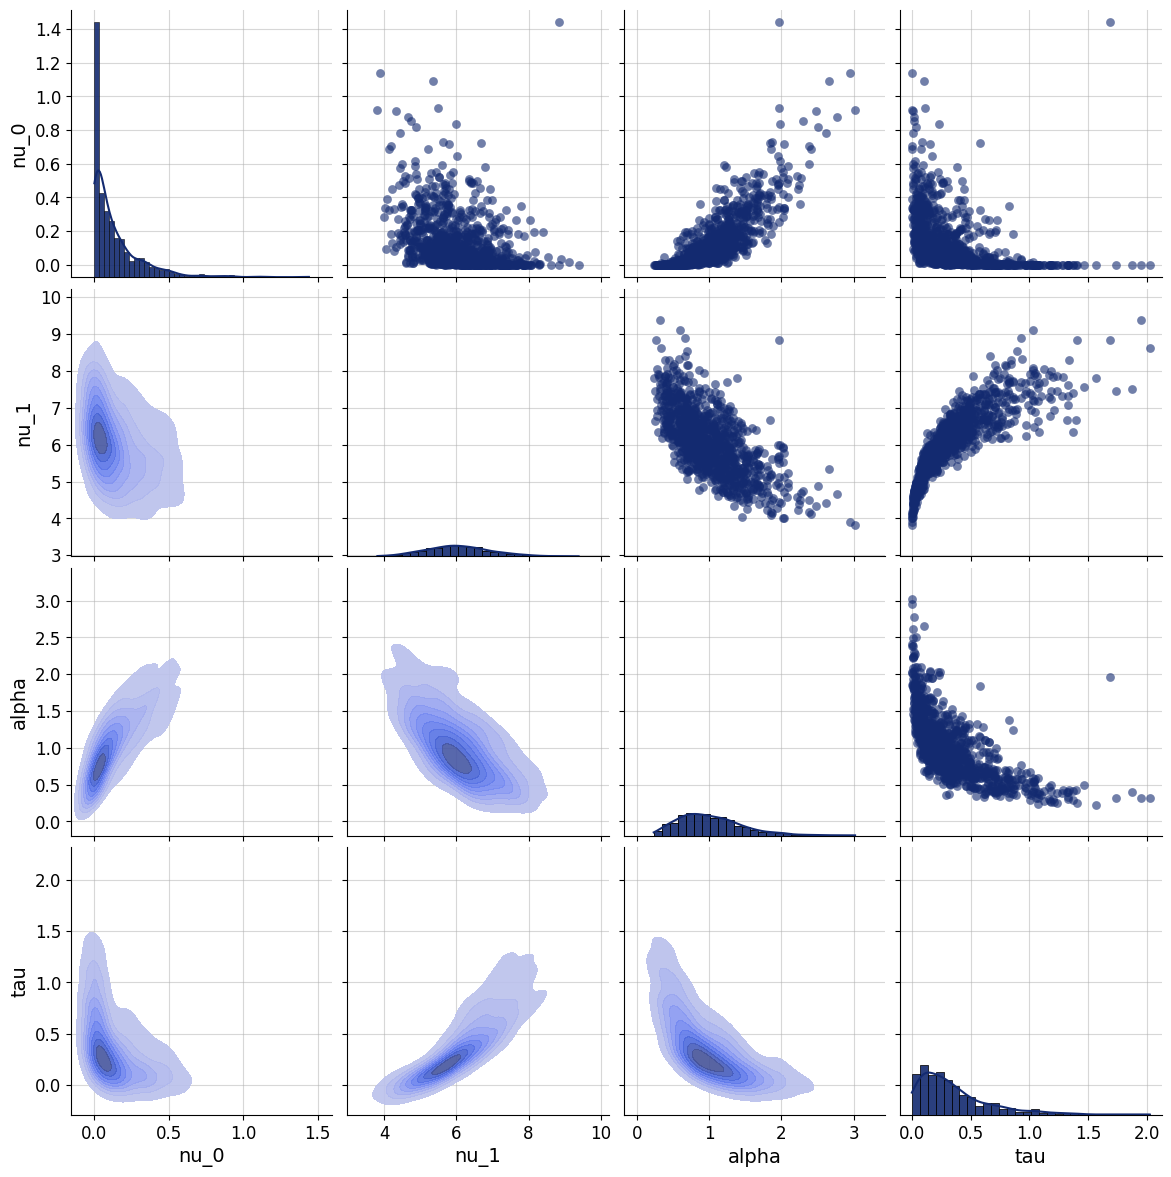

In [60]:
f=bf.diagnostics.pairs_posterior(estimates=posterior_fourth)

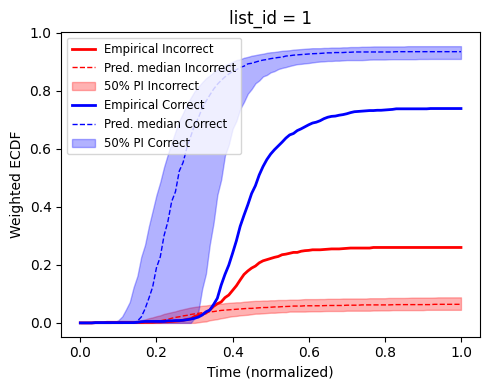

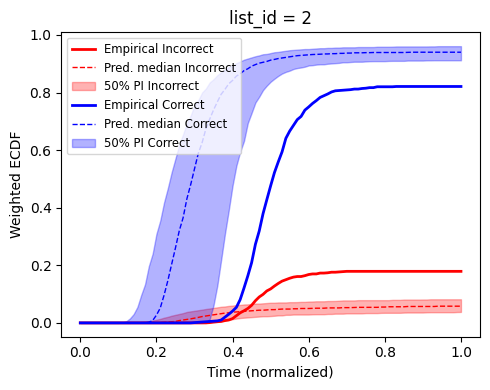

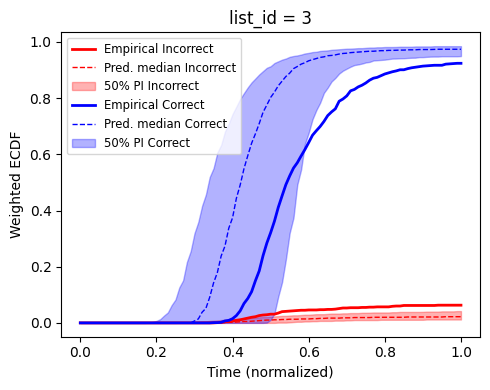

C:\Users\MOHOR\anaconda3\envs\bf\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\MOHOR\anaconda3\envs\bf\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


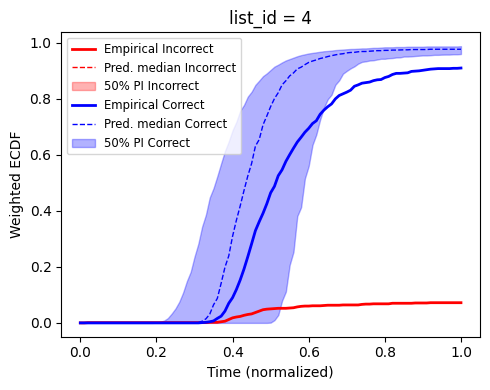

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# ——— ECDF on a fixed grid ——————————————————————
def ecdf_grid(Time1, Correct, t_grid):
    valid    = ~np.isnan(Time1)
    mask_inc = valid & (~Correct)
    mask_cor = valid &  (Correct)
    p_inc = mask_inc.sum() / valid.sum()
    p_cor = mask_cor.sum() / valid.sum()
    ec0 = p_inc * np.array([np.mean(Time1[mask_inc] <= x) for x in t_grid])
    ec1 = p_cor * np.array([np.mean(Time1[mask_cor] <= x) for x in t_grid])
    return np.stack([ec0, ec1], axis=0)  # shape (2, len(t_grid))

# Colors & labels
cols   = ["red","blue"]
labels = ["Incorrect","Correct"]

# Common grid (normalized 0→1)
t_grid = np.linspace(0, 1, 101)

# Loop over each list_id
for idx, list_id in enumerate(grouped.groups):
    # 1) empirical data for this participant
    df_i = grouped.get_group(list_id).reset_index(drop=True)
    emp_ecdf = ecdf_grid(
        Time1   = df_i["Time1"].to_numpy(),
        Correct = df_i["Correct"].to_numpy(),
        t_grid  = t_grid
    )  # (2,101)

    # 2) get posterior draws for this participant
    post_i = {param: arr[idx] for param, arr in posterior_samples.items()}
    # shapes: post_i["nu"]    → (n_draws, 2)
    #         post_i["alpha"] → (n_draws, 1)
    #         post_i["tau"]   → (n_draws, 1)
    n_draws = post_i["nu"].shape[0]
    n_trials = df_i.shape[0]

    # 3) simulate posterior‐predictive ECDFs
    pp_ecdfs = np.zeros((n_draws, 2, len(t_grid)))
    for j in range(n_draws):
        nu_j    = post_i["nu"][j]             # shape (2,)
        alpha_j = post_i["alpha"][j, 0]       # scalar
        tau_j   = post_i["tau"][j, 0]         # scalar

        out = likelihood(
            n     = n_trials,
            nu    = nu_j,
            alpha = alpha_j,
            tau   = tau_j,
            max_n = n_trials
        )
        pp_ecdfs[j] = ecdf_grid(
            Time1   = out["Time1"],
            Correct = out["Correct"],
            t_grid  = t_grid
        )

    # 4) compute quantiles (25, 50, 75%) across the draws
    q25, q50, q75 = np.quantile(pp_ecdfs, [0.25, 0.50, 0.75], axis=0)

    # 5) plot
    plt.figure(figsize=(5,4))
    for k, lab in enumerate(labels):
        # empirical
        plt.plot(t_grid, emp_ecdf[k], color=cols[k], lw=2, label=f"Empirical {lab}")
        # median predictive
        plt.plot(t_grid, q50[k],   color=cols[k], lw=1, ls="--", label=f"Pred. median {lab}")
        # 50% PI
        plt.fill_between(
            t_grid,
            q25[k],
            q75[k],
            color=cols[k], alpha=0.3,
            label=f"50% PI {lab}"
        )

    plt.xlabel("Time (normalized)")
    plt.ylabel("Weighted ECDF")
    plt.title(f"list_id = {list_id}")
    plt.legend(fontsize="small", loc="upper left")
    plt.tight_layout()
    plt.show()


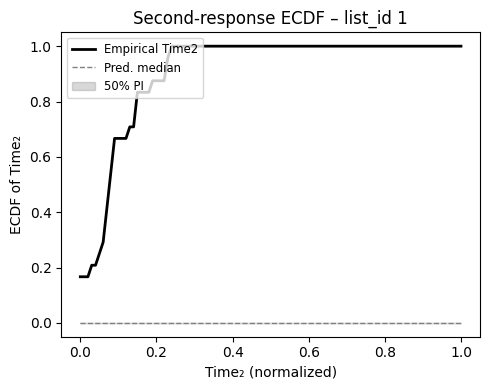

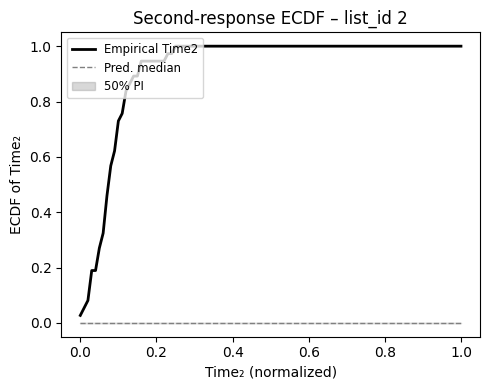

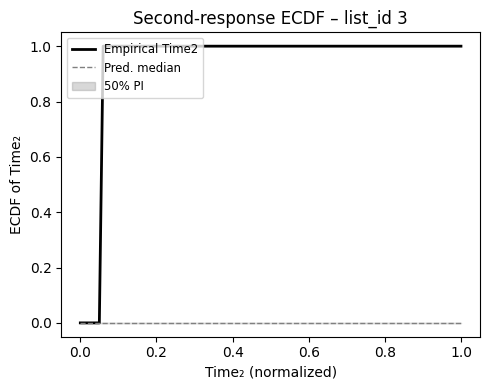

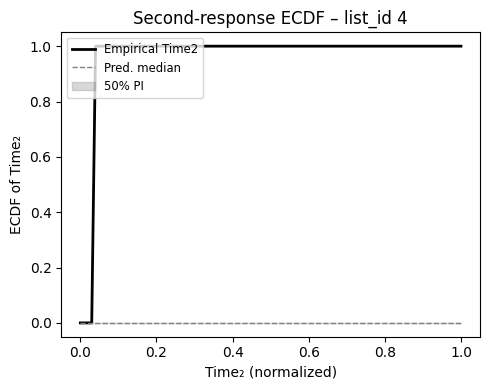

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# ——— ECDF for Time2 on double‐response trials —————————————————
def ecdf_time2(Time2, DoubleResp, t_grid):
    """
    Univariate ECDF of second‐response RTs on double‐response trials.
    Returns an array of shape (len(t_grid),).
    """
    mask = DoubleResp.astype(bool) & ~np.isnan(Time2)
    if not mask.any():
        return np.zeros_like(t_grid)
    times = Time2[mask]
    return np.array([np.mean(times <= x) for x in t_grid])

# Common grid (normalized 0→1)
t_grid = np.linspace(0, 1, 101)

for idx, list_id in enumerate(grouped.groups):
    df_i = grouped.get_group(list_id).reset_index(drop=True)

    # 1) empirical ECDF for Time2
    emp_ecdf = ecdf_time2(
        Time2      = df_i["Time2"].to_numpy(),
        DoubleResp = df_i["DoubleResp"].to_numpy(),
        t_grid     = t_grid
    )

    # 2) posterior draws
    post_i    = {p: arr[idx] for p, arr in posterior_samples.items()}
    n_draws   = post_i["nu"].shape[0]
    n_trials  = df_i.shape[0]

    # 3) simulate predictive ECDFs
    pp_ecdfs = np.zeros((n_draws, len(t_grid)))
    for j in range(n_draws):
        out = likelihood(
            n     = n_trials,
            nu    = post_i["nu"][j],
            alpha = post_i["alpha"][j, 0],
            tau   = post_i["tau"][j, 0],
            max_n = n_trials
        )
        pp_ecdfs[j] = ecdf_time2(
            Time2      = out["Time2"],
            DoubleResp = out["DoubleResp"],
            t_grid     = t_grid
        )

    # 4) predictive quantiles
    q25, q50, q75 = np.quantile(pp_ecdfs, [0.25, 0.5, 0.75], axis=0)

    # 5) plot
    plt.figure(figsize=(5,4))
    plt.plot(t_grid, emp_ecdf, color="black", lw=2, label="Empirical Time2")
    plt.plot(t_grid, q50,     color="gray",  lw=1, ls="--", label="Pred. median")
    plt.fill_between(t_grid, q25, q75, color="gray", alpha=0.3, label="50% PI")

    plt.xlabel("Time₂ (normalized)")
    plt.ylabel("ECDF of Time₂")
    plt.title(f"Second‑response ECDF – list_id {list_id}")
    plt.legend(fontsize="small", loc="upper left")
    plt.tight_layout()
    plt.show()


In [47]:
import numpy as np

# 1) Simulate n_test “datasets” from your simulator
n_test    = 1000
test_sims = simulator.sample(n_test)

# 2) Prepare the conditions dict with correct dtypes & shapes
#    summary variables need shape (n_test, n_trials, 1) and float32
n_trials = test_sims["Time1"].shape[1]  # e.g. 1000
conditions = {
    "Correct":    test_sims["Correct"].astype(np.float32).reshape(n_test, n_trials, 1),
    "Time1":      test_sims["Time1"].astype(np.float32).reshape(n_test, n_trials, 1),
    "DoubleResp": test_sims["DoubleResp"].astype(np.float32).reshape(n_test, n_trials, 1),
    "Time2":      test_sims["Time2"].astype(np.float32).reshape(n_test, n_trials, 1),
    "n":          test_sims["n"].astype(np.int32)  # shape (n_test,)
}

# 3) Draw num_pp_samples posterior draws per dataset
num_pp_samples = 1000
posterior_sims = workflow.sample(
    conditions  = conditions,
    num_samples = num_pp_samples
)

# Quick sanity‐check
for k, v in posterior_sims.items():
    print(f"{k:12s} → shape {v.shape}  NaNs {np.isnan(v).sum()}")


nu           → shape (1000, 1000, 2)  NaNs 0
alpha        → shape (1000, 1000, 1)  NaNs 0
tau          → shape (1000, 1000, 1)  NaNs 0


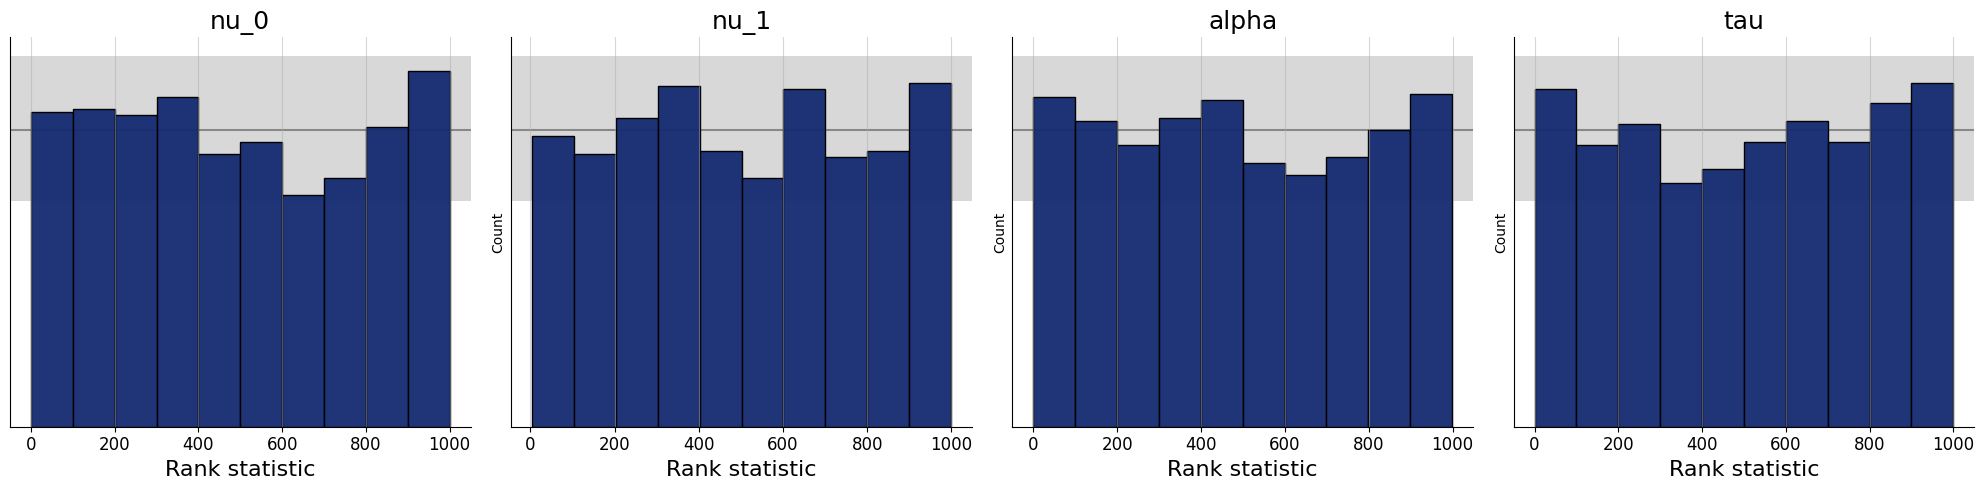

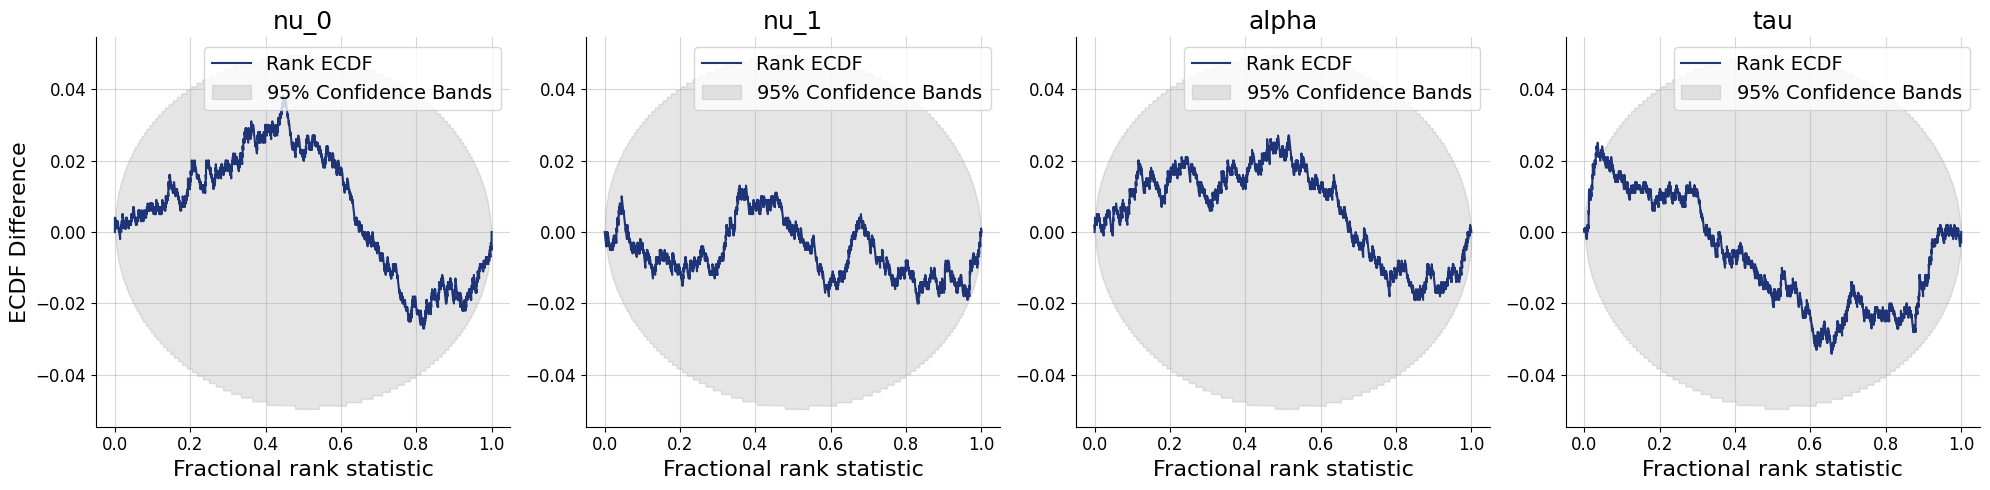

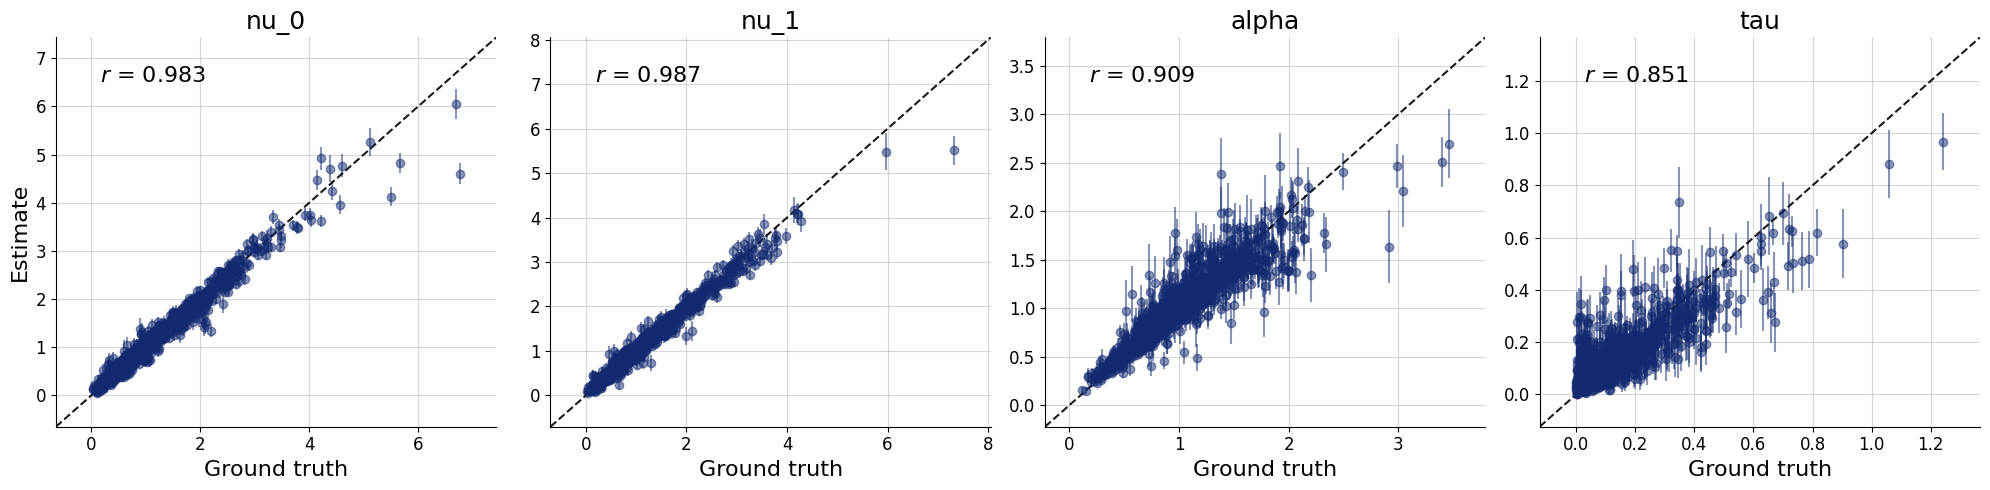

In [48]:
import bayesflow as bf

# 4) Calibration histogram for each parameter
f_hist = bf.diagnostics.plots.calibration_histogram(
    posterior_sims,   # estimates dict from step A
    test_sims         # ground‐truth dict from step A
)

# 5) Calibration ECDF‐difference plot
f_ecdf = bf.diagnostics.plots.calibration_ecdf(
    posterior_sims,
    test_sims,
    difference=True
)

# 6) Recovery / scatter (true vs. inferred)
f_recov = bf.diagnostics.plots.recovery(
    posterior_sims,
    test_sims
)



In [49]:
# 7) Metric summaries (e.g. coverage probabilities, bias, corr)
metrics = workflow.compute_default_diagnostics(test_data=test_sims)
print(metrics)


                           nu_0      nu_1     alpha       tau
NRMSE                  0.030538  0.026192  0.076739  0.087820
Posterior Contraction  0.985959  0.986463  0.928548  0.865750
Calibration Error      0.023132  0.007263  0.014158  0.030711
